Import Libraries

In [20]:
!pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [21]:
!pip install geodatasets


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [22]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# GeoPandas
import geopandas as gpd

# Settings
sns.set(style="whitegrid")

Load Data

In [23]:
# Load dataset
df = pd.read_csv("EcommerceData.csv", encoding='ISO-8859-1')

# Preview
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


Inspecting Data

In [24]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


Data Cleaning

In [25]:
# Remove missing CustomerID
df = df.dropna(subset=['CustomerID'])

# Remove negative or zero quantity
df = df[df['Quantity'] > 0]

# Remove negative prices
df = df[df['UnitPrice'] > 0]

# Remove duplicates
df = df.drop_duplicates()

# Convert date column
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Check result
df.info()

<class 'pandas.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  str           
 1   StockCode    392692 non-null  str           
 2   Description  392692 non-null  str           
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[us]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 27.0 MB


Feature Engineering

In [26]:
# Create TotalPrice
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Time features
df['Hour'] = df['InvoiceDate'].dt.hour
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
df['Month'] = df['InvoiceDate'].dt.month_name()

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Hour,DayOfWeek,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,8,Wednesday,December
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,8,Wednesday,December
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,8,Wednesday,December
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,8,Wednesday,December
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,8,Wednesday,December


Exploratory data analysis

In [27]:
total_customers = df['CustomerID'].nunique()
total_transactions = df['InvoiceNo'].nunique()
total_revenue = df['TotalPrice'].sum()
avg_order_value = df.groupby('InvoiceNo')['TotalPrice'].sum().mean()

print("Total Customers:", total_customers)
print("Total Transactions:", total_transactions)
print("Total Revenue:", round(total_revenue, 2))
print("Average Order Value:", round(avg_order_value, 2))

Total Customers: 4338
Total Transactions: 18532
Total Revenue: 8887208.89
Average Order Value: 479.56


Histogram of Total Price

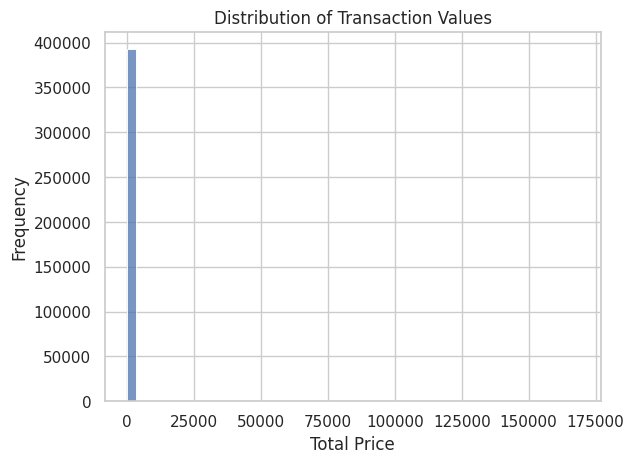

In [28]:
plt.figure()
sns.histplot(df['TotalPrice'], bins=50)
plt.title("Distribution of Transaction Values")
plt.xlabel("Total Price")
plt.ylabel("Frequency")
plt.show()

Top 10 Products

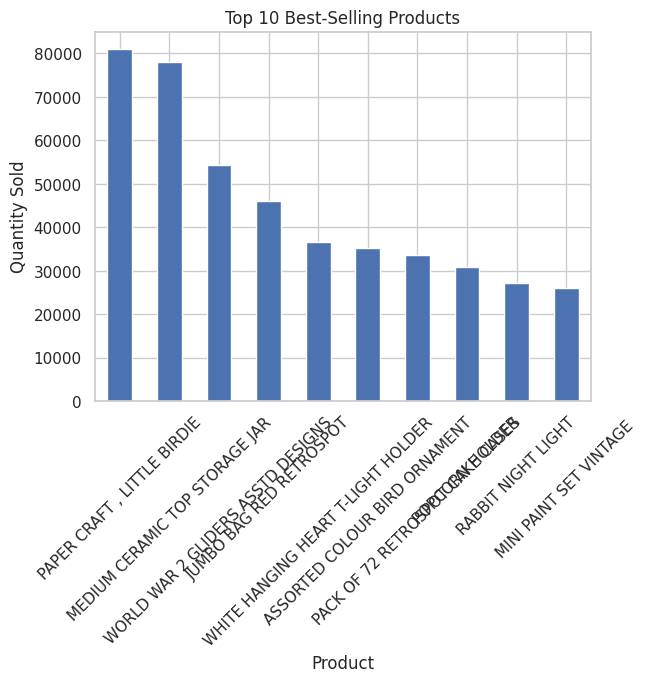

In [29]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure()
top_products.plot(kind='bar')
plt.title("Top 10 Best-Selling Products")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)
plt.show()

HeatMap

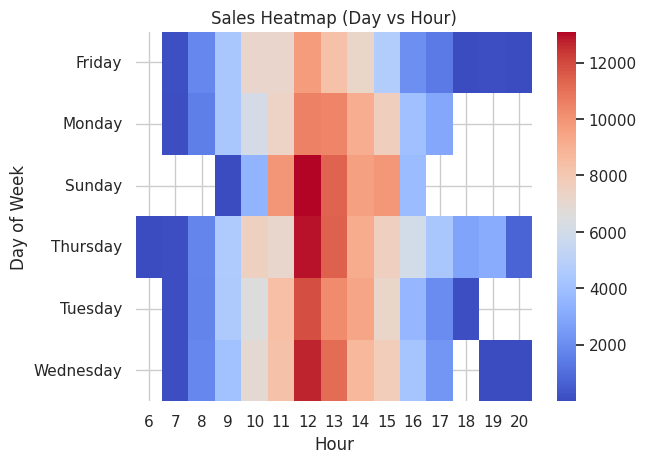

In [30]:
pivot_table = df.pivot_table(
    values='InvoiceNo',
    index='DayOfWeek',
    columns='Hour',
    aggfunc='count'
)

plt.figure()
sns.heatmap(pivot_table, cmap="coolwarm")
plt.title("Sales Heatmap (Day vs Hour)")
plt.xlabel("Hour")
plt.ylabel("Day of Week")
plt.show()

BoxPlot Order Value By Country

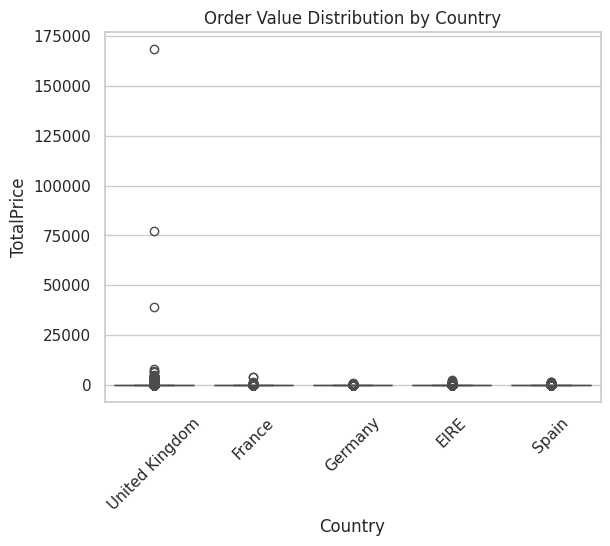

In [31]:
top_countries = df['Country'].value_counts().head(5).index
filtered_df = df[df['Country'].isin(top_countries)]

plt.figure()
sns.boxplot(data=filtered_df, x='Country', y='TotalPrice')
plt.title("Order Value Distribution by Country")
plt.xticks(rotation=45)
plt.show()

GEO Data

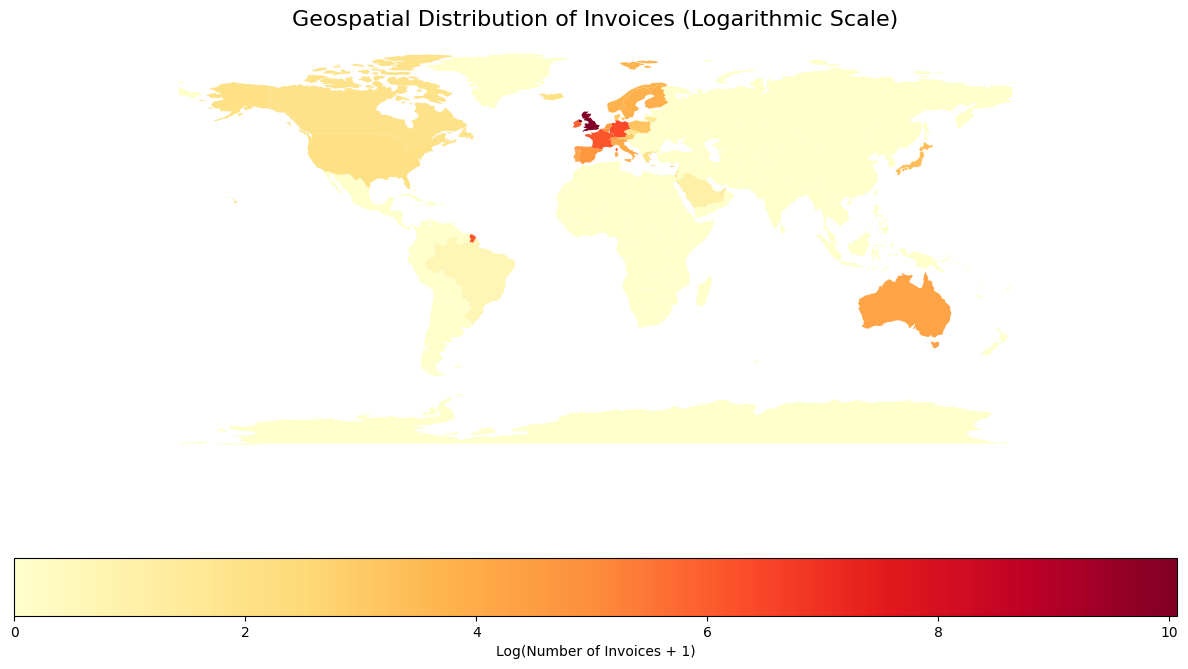

           Country  InvoiceCount
36  United Kingdom         23494
14         Germany           603
13          France           461
10         Ireland           360
3          Belgium           119
31           Spain           105
24     Netherlands           101
33     Switzerland            74
27        Portugal            71
0        Australia            69


In [6]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

# 1. Load data with the correct encoding
df = pd.read_csv('EcommerceData.csv', encoding='ISO-8859-1')

# 2. Aggregate: Count unique invoices per country
# We count unique InvoiceNo to get the number of distinct orders
invoice_counts = df.groupby('Country')['InvoiceNo'].nunique().reset_index()
invoice_counts.columns = ['Country', 'InvoiceCount']

# 3. Load the world map from a URL (GeoPandas 1.0+ approach)
world_url = "https://raw.githubusercontent.com/python-visualization/folium/master/examples/data/world-countries.json"
world = gpd.read_file(world_url)

# 4. Clean country names for better merging
# The map uses 'United Kingdom' and 'Ireland', while the data may use 'UK' or 'EIRE'
name_mapping = {
    'EIRE': 'Ireland',
    'USA': 'United States of America',
}
invoice_counts['Country'] = invoice_counts['Country'].replace(name_mapping)

# 5. Merge the datasets
# We merge on the map's 'name' and our data's 'Country'
merged = world.merge(invoice_counts, left_on='name', right_on='Country', how='left')
merged['InvoiceCount'] = merged['InvoiceCount'].fillna(0)

# 6. Create the Choropleth Map
# Since the UK is a massive outlier, we use a Log Scale for better color distribution
merged['LogInvoiceCount'] = np.log1p(merged['InvoiceCount'])

fig, ax = plt.subplots(1, 1, figsize=(15, 8))
merged.plot(column='LogInvoiceCount', 
            ax=ax, 
            legend=True, 
            cmap='YlOrRd',
            legend_kwds={'label': "Log(Number of Invoices + 1)", 'orientation': "horizontal"},
            missing_kwds={"color": "lightgrey"})

plt.title('Geospatial Distribution of Invoices (Logarithmic Scale)', fontsize=16)
plt.axis('off')
plt.show()

# Display the top 10 countries for interpretation
print(invoice_counts.sort_values('InvoiceCount', ascending=False).head(10))

Interpretation of Geographic Trends
United Kingdom Dominance: The data shows a massive concentration of activity in the United Kingdom (over 23,000 invoices). This suggests that the retailer is either UK-based or has a primary market focus there, as the UK volume is nearly 40x higher than the next closest country.

European Core Hub: The strongest international markets are clustered in Western Europe, specifically Germany, France, and Ireland. This indicates high brand penetration in regions with close logistical proximity to the UK.

The "Proximity Effect": There is a clear correlation between geographic distance and invoice volume. Sales are densest in Northern and Western Europe, while markets in the Americas and Asia (like Japan or the USA) show much lower, sporadic activity.